#### ============================================================
## Fashion Product Image Classification using CNNs
#### Dataset: Fashion Product Images (Small) - Kaggle
#### https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small
#### ============================================================

#### ─────────────────────────────────────────────
### SECTION 1: Install & Import Libraries
#### ─────────────────────────────────────────────

In [1]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import Counter

import cv2
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, VGG16
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import plot_model

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')

2026-06-07 16:57:47.583091: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780851467.789050      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780851467.845114      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780851468.307997      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780851468.308087      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780851468.308090      23 computation_placer.cc:177] computation placer alr

In [2]:
# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.19.0
GPU Available: True


#### ─────────────────────────────────────────────
### SECTION 2: Configuration
#### ─────────────────────────────────────────────

In [3]:
# Kaggle dataset path — adjust if running locally
DATA_DIR    = Path("/kaggle/input/datasets/paramaggarwal/fashion-product-images-small")
IMAGES_DIR  = DATA_DIR / "images"
STYLES_CSV  = DATA_DIR / "styles.csv"
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

# Model hyperparameters
IMG_SIZE      = (128, 128)      # Resize all images to this
BATCH_SIZE    = 32
EPOCHS_CNN    = 30
EPOCHS_TL     = 20
LEARNING_RATE = 2e-3
MIN_SAMPLES   = 300             # Minimum images per class to include
TOP_N_CLASSES = 10              # Number of top classes to use

#### ─────────────────────────────────────────────
### SECTION 3: Dataset Loading & Exploration
#### ─────────────────────────────────────────────


In [4]:
# Load styles metadata CSV
df = pd.read_csv(STYLES_CSV, on_bad_lines='skip')
print(f"Total records in CSV: {len(df)}")
print(df.head())
print("\nColumn names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)

# We classify by 'masterCategory' which has broad product types
# (Apparel, Footwear, Accessories, etc.)
TARGET_COL = 'masterCategory'
print(f"\nTarget column: '{TARGET_COL}'")
print(f"Unique classes: {df[TARGET_COL].nunique()}")
print(df[TARGET_COL].value_counts())

Total records in CSV: 44424
      id gender masterCategory subCategory  articleType baseColour  season  \
0  15970    Men        Apparel     Topwear       Shirts  Navy Blue    Fall   
1  39386    Men        Apparel  Bottomwear        Jeans       Blue  Summer   
2  59263  Women    Accessories     Watches      Watches     Silver  Winter   
3  21379    Men        Apparel  Bottomwear  Track Pants      Black    Fall   
4  53759    Men        Apparel     Topwear      Tshirts       Grey  Summer   

     year   usage                             productDisplayName  
0  2011.0  Casual               Turtle Check Men Navy Blue Shirt  
1  2012.0  Casual             Peter England Men Party Blue Jeans  
2  2016.0  Casual                       Titan Women Silver Watch  
3  2011.0  Casual  Manchester United Men Solid Black Track Pants  
4  2012.0  Casual                          Puma Men Grey T-shirt  

Column names: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season

In [5]:
# Build a valid image path for each row
df['image_path'] = df['id'].astype(str).apply(
    lambda x: str(IMAGES_DIR / (x + '.jpg'))
)

# Keep only rows where the image actually exists on disk
df['exists'] = df['image_path'].apply(os.path.exists)
df = df[df['exists']].copy()
print(f"\nImages found on disk: {len(df)}")

# Drop rows with missing target
df = df.dropna(subset=[TARGET_COL])
print(f"After dropping NaN targets: {len(df)}")


Images found on disk: 44419
After dropping NaN targets: 44419


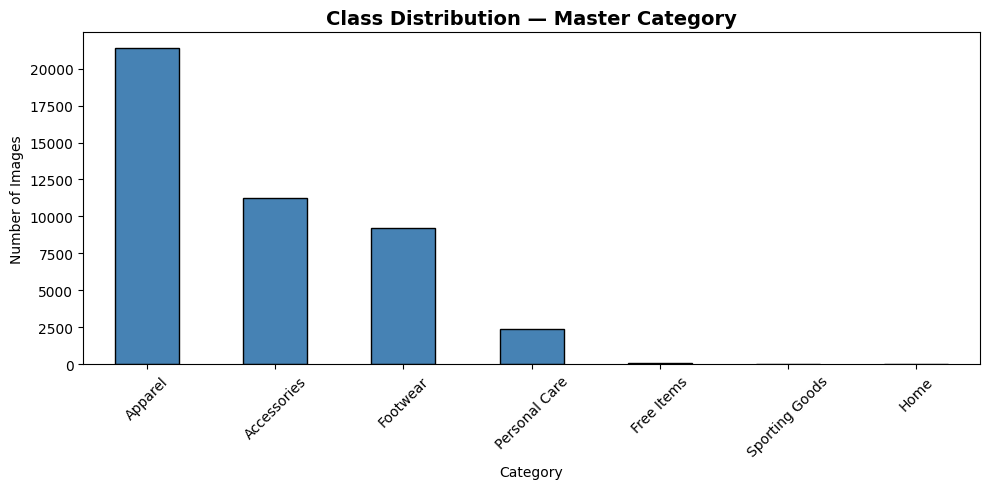

Figure saved: class_distribution.png


In [6]:
# ── 3a. Class distribution plot ──
class_counts = df[TARGET_COL].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
class_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title("Class Distribution — Master Category", fontsize=14, fontweight='bold')
ax.set_xlabel("Category")
ax.set_ylabel("Number of Images")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_distribution.png", dpi=150)
plt.show()
print("Figure saved: class_distribution.png")

In [7]:
# ── 3b. Filter to TOP_N_CLASSES with MIN_SAMPLES ──
valid_classes = class_counts[class_counts >= MIN_SAMPLES].index.tolist()
valid_classes = valid_classes[:TOP_N_CLASSES]
df = df[df[TARGET_COL].isin(valid_classes)].copy()
print(f"\nSelected {len(valid_classes)} classes: {valid_classes}")
print(f"Dataset size after filtering: {len(df)}")


Selected 4 classes: ['Apparel', 'Accessories', 'Footwear', 'Personal Care']
Dataset size after filtering: 44288


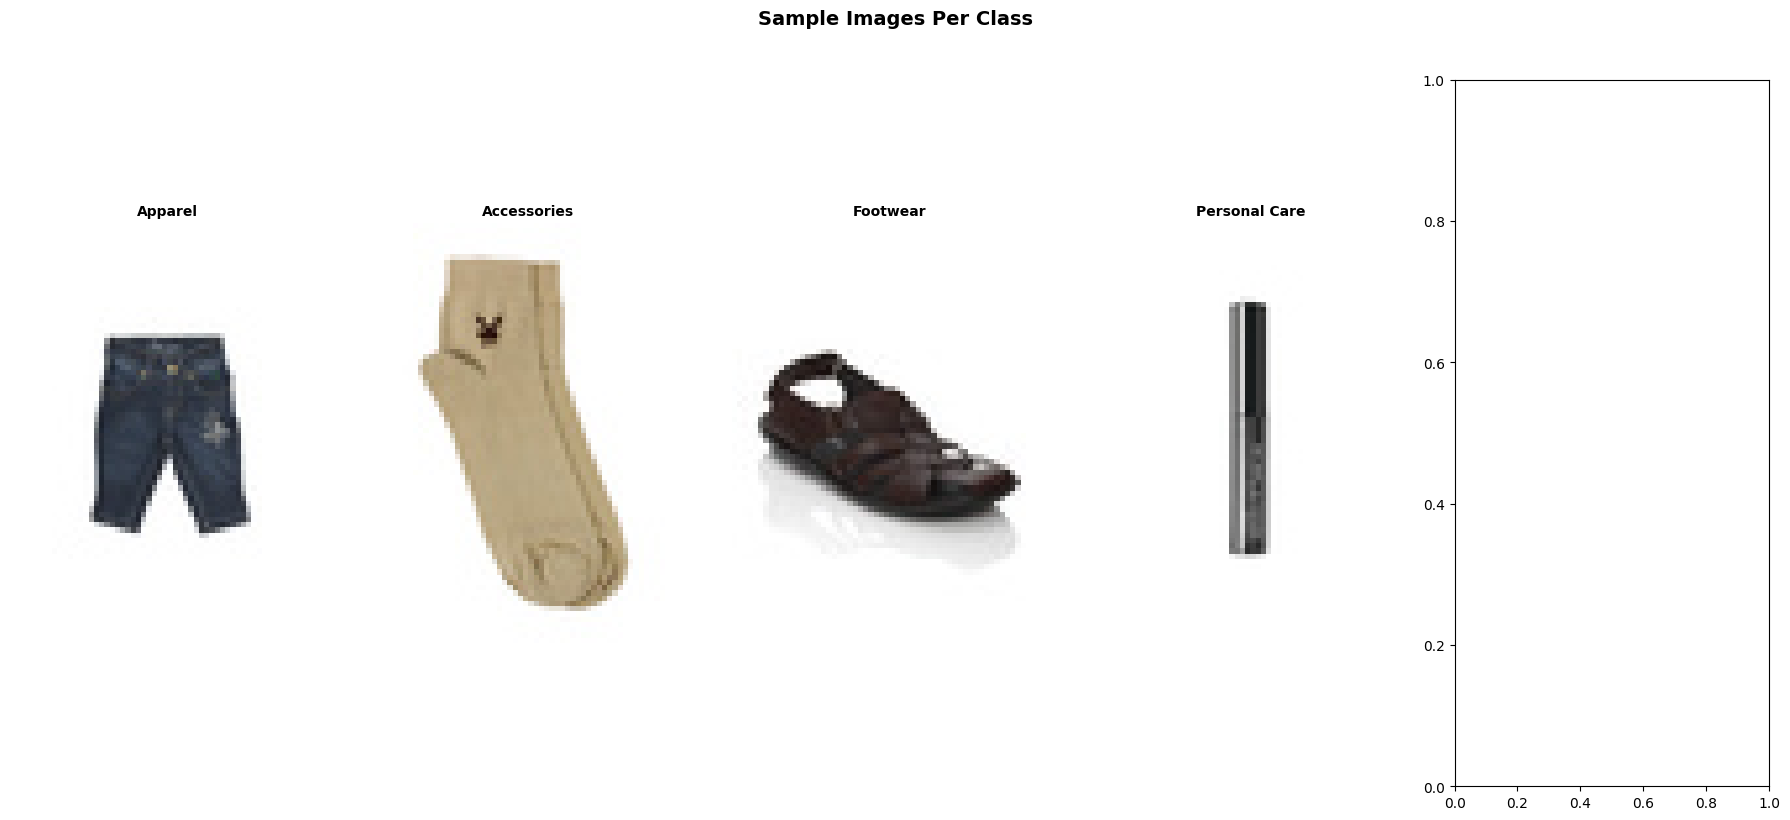

Figure saved: sample_images.png


In [8]:
# ── 3c. Sample images visualisation ──
fig, axes = plt.subplots(1, 5, figsize=(18, 8))
axes = axes.flatten()
for i, cls in enumerate(valid_classes[:10]):
    sample = df[df[TARGET_COL] == cls].sample(1, random_state=SEED).iloc[0]
    img = Image.open(sample['image_path']).convert('RGB')
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=10, fontweight='bold')
    axes[i].axis('off')
plt.suptitle("Sample Images Per Class", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sample_images.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: sample_images.png")

#### ─────────────────────────────────────────────
### SECTION 4: Preprocessing & Train/Val/Test Split
#### ─────────────────────────────────────────────


In [9]:
# Encode string labels to integers
class_to_idx = {cls: i for i, cls in enumerate(sorted(valid_classes))}
idx_to_class = {v: k for k, v in class_to_idx.items()}
df['label'] = df[TARGET_COL].map(class_to_idx)
NUM_CLASSES = len(class_to_idx)
print(f"Number of classes: {NUM_CLASSES}")
print("Label mapping:", class_to_idx)

# 70 / 15 / 15  train / val / test split (stratified)
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df['label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['label']
)
print(f"\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


def load_and_preprocess(image_path, img_size=IMG_SIZE):
    """Load image from disk, resize, and normalise to [0, 1]."""
    img = Image.open(image_path).convert('RGB')
    img = img.resize(img_size, Image.LANCZOS)
    arr = np.array(img, dtype=np.float32) / 255.0
    return arr


def build_arrays(dataframe, img_size=IMG_SIZE):
    """Convert dataframe rows to (X, y) numpy arrays."""
    X, y = [], []
    for _, row in dataframe.iterrows():
        try:
            arr = load_and_preprocess(row['image_path'], img_size)
            X.append(arr)
            y.append(row['label'])
        except Exception:
            pass  # Skip corrupted images
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)


print("\nLoading train set ...")
X_train, y_train = build_arrays(train_df)
print(f"  X_train: {X_train.shape}  y_train: {y_train.shape}")

print("Loading val set ...")
X_val, y_val = build_arrays(val_df)
print(f"  X_val:   {X_val.shape}  y_val: {y_val.shape}")

print("Loading test set ...")
X_test, y_test = build_arrays(test_df)
print(f"  X_test:  {X_test.shape}  y_test: {y_test.shape}")

# Pixel statistics (sanity check)
print(f"\nPixel range: [{X_train.min():.3f}, {X_train.max():.3f}]")
print(f"Mean pixel value: {X_train.mean():.3f}")

Number of classes: 4
Label mapping: {'Accessories': 0, 'Apparel': 1, 'Footwear': 2, 'Personal Care': 3}

Train: 31001 | Val: 6643 | Test: 6644

Loading train set ...
  X_train: (31001, 128, 128, 3)  y_train: (31001,)
Loading val set ...
  X_val:   (6643, 128, 128, 3)  y_val: (6643,)
Loading test set ...
  X_test:  (6644, 128, 128, 3)  y_test: (6644,)

Pixel range: [0.000, 1.000]
Mean pixel value: 0.840


#### ─────────────────────────────────────────────
### SECTION 5: Data Augmentation
#### ─────────────────────────────────────────────

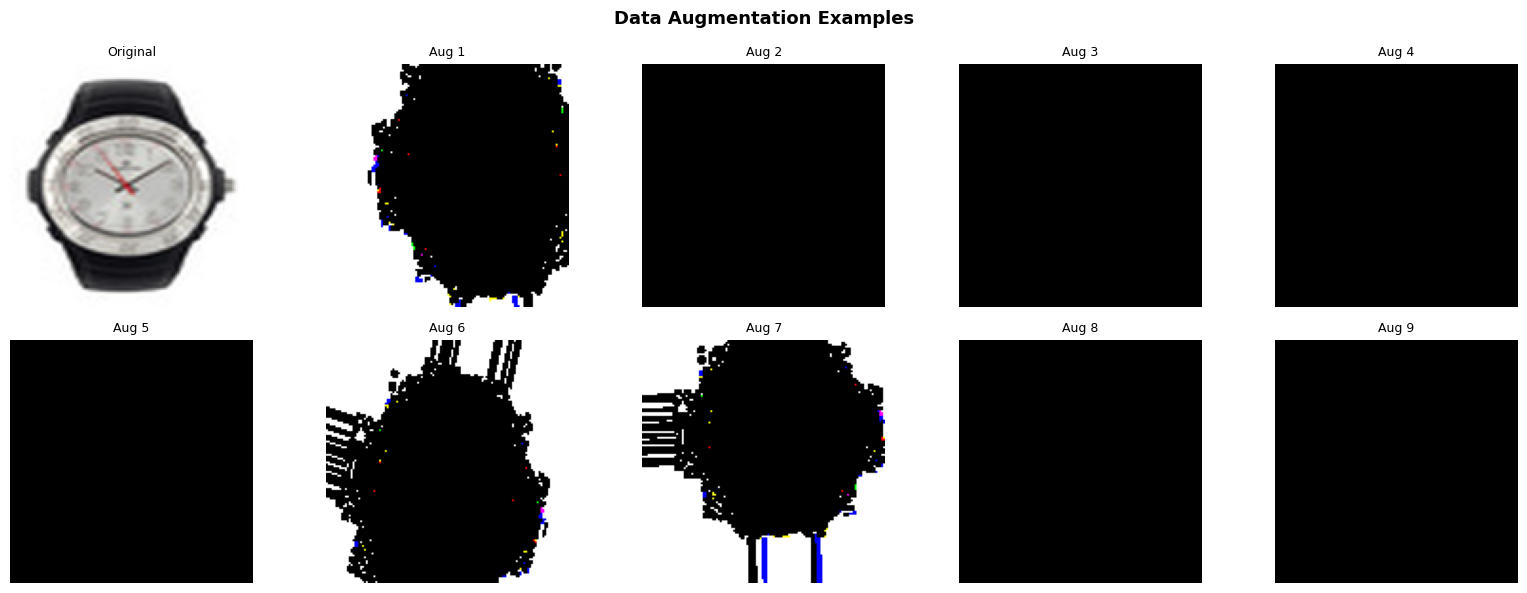

Figure saved: augmentation_examples.png


In [10]:
# Augmentation is applied ONLY to the training set via ImageDataGenerator
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# Val/Test use no augmentation — just pass through
val_datagen   = ImageDataGenerator()
test_datagen  = ImageDataGenerator()

# Create TF generators from arrays
train_gen = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=SEED)
val_gen   = val_datagen.flow(X_val,   y_val,   batch_size=BATCH_SIZE, shuffle=False)
test_gen  = test_datagen.flow(X_test,  y_test,  batch_size=BATCH_SIZE, shuffle=False)

# ── Visualise augmentation ──
sample_img = X_train[0:1]
aug_gen    = train_datagen.flow(sample_img, batch_size=1)

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
axes = axes.flatten()
axes[0].imshow(sample_img[0])
axes[0].set_title("Original", fontsize=9)
axes[0].axis('off')
for i in range(1, 10):
    aug_img = next(aug_gen)[0]
    axes[i].imshow(np.clip(aug_img, 0, 1))
    axes[i].set_title(f"Aug {i}", fontsize=9)
    axes[i].axis('off')
plt.suptitle("Data Augmentation Examples", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "augmentation_examples.png", dpi=150)
plt.show()
print("Figure saved: augmentation_examples.png")

#### ─────────────────────────────────────────────
### SECTION 6: Custom CNN Model
#### ─────────────────────────────────────────────


In [11]:
def build_custom_cnn(input_shape, num_classes):
    """
    A 6-block custom CNN.

    Architecture overview:
      Block 1-2 : Conv → BN → ReLU → Conv → BN → ReLU → MaxPool → Dropout
      Block 3-4 : Same pattern, deeper filters
      Block 5-6 : Same pattern, deepest filters
      Head       : GlobalAvgPool → Dense(256) → BN → Dropout → Softmax
    """
    inp = keras.Input(shape=input_shape, name="input_image")

    # ── Block 1 ──
    x = layers.Conv2D(32, 3, padding='same', name='conv1a')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, 3, padding='same', name='conv1b')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # ── Block 2 ──
    x = layers.Conv2D(64, 3, padding='same', name='conv2a')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, 3, padding='same', name='conv2b')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # ── Block 3 ──
    x = layers.Conv2D(128, 3, padding='same', name='conv3a')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, 3, padding='same', name='conv3b')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.30)(x)

    # ── Block 4 ──
    x = layers.Conv2D(256, 3, padding='same', name='conv4a')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(256, 3, padding='same', name='conv4b')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.30)(x)

    # ── Classification Head ──
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, name='fc1')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.50)(x)
    out = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    return keras.Model(inputs=inp, outputs=out, name="CustomCNN")


cnn_model = build_custom_cnn(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=NUM_CLASSES
)
cnn_model.summary()

# Save architecture diagram
try:
    plot_model(cnn_model, to_file=str(FIGURES_DIR / "cnn_architecture.png"),
               show_shapes=True, show_layer_names=True, dpi=80)
    print("Figure saved: cnn_architecture.png")
except Exception as e:
    print(f"(Architecture plot skipped: {e})")

I0000 00:00:1780851661.788613      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "CustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1a (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1b (Conv2D)                 │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2a (Conv2D)                 │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2b (Conv2D)                 │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3a (Conv2D)                 │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3b (Conv2D)                 │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 1,243,940 (4.75 MB)

 Trainable params: 1,241,508 (4.74 MB)

 Non-trainable params: 2,432 (9.50 KB)

Figure saved: cnn_architecture.png


#### ─────────────────────────────────────────────
### SECTION 7: Training the Custom CNN
#### ─────────────────────────────────────────────

Epoch 1/30


I0000 00:00:1780851670.015618      70 service.cc:152] XLA service 0x7db258004650 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780851670.015676      70 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1780851671.153793      70 cuda_dnn.cc:529] Loaded cuDNN version 91002


  3/968 ━━━━━━━━━━━━━━━━━━━━ 1:15 78ms/step - accuracy: 0.2882 - loss: 1.6526  

I0000 00:00:1780851681.665575      70 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


968/968 ━━━━━━━━━━━━━━━━━━━━ 157s 144ms/step - accuracy: 0.5795 - loss: 0.9800 - val_accuracy: 0.2544 - val_loss: 3.1726 - learning_rate: 0.0020
Epoch 2/30
968/968 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6562 - loss: 0.8548 - val_accuracy: 0.2544 - val_loss: 3.0316 - learning_rate: 0.0020
Epoch 3/30
968/968 ━━━━━━━━━━━━━━━━━━━━ 125s 129ms/step - accuracy: 0.6442 - loss: 0.8659 - val_accuracy: 0.2544 - val_loss: 3.4045 - learning_rate: 0.0020
Epoch 4/30
968/968 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6250 - loss: 0.9593 - val_accuracy: 0.2544 - val_loss: 3.3056 - learning_rate: 0.0020
Epoch 5/30
968/968 ━━━━━━━━━━━━━━━━━━━━ 122s 126ms/step - accuracy: 0.6600 - loss: 0.8269 - val_accuracy: 0.2547 - val_loss: 2.2982 - learning_rate: 0.0020
Epoch 6/30
968/968 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9062 - loss: 0.4921 - val_accuracy: 0.2547 - val_loss: 2.3404 - learning_rate: 0.0020
Epoch 7/30
968/968 ━━━━━━━━━━━━━━━━━━━━ 118s 122ms/step - accuracy: 0.6697 - loss: 0.80

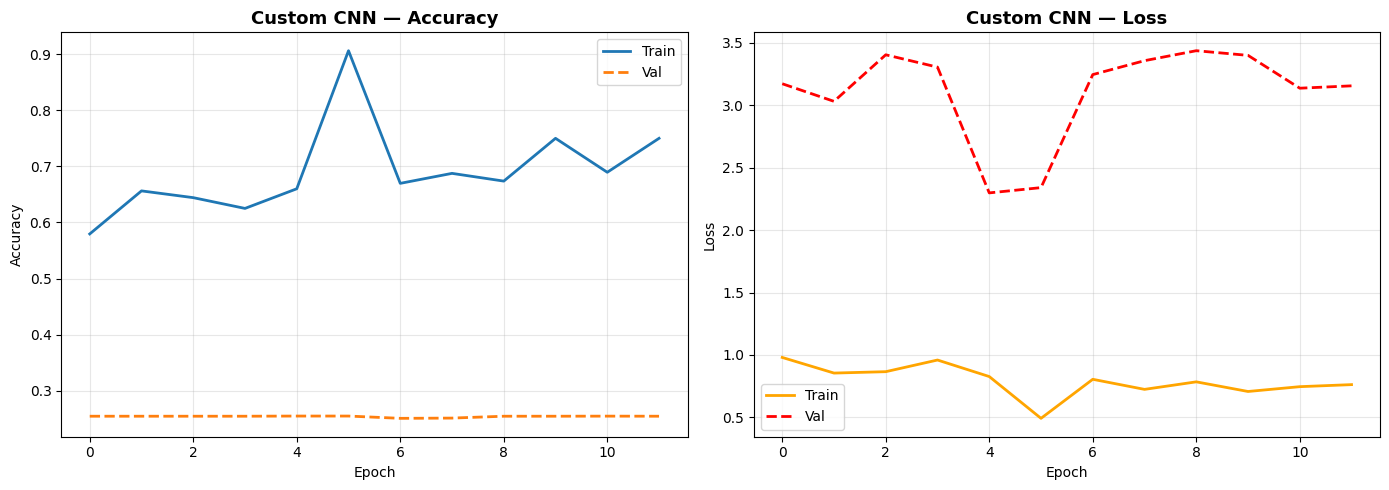

Figure saved: cnn_training_curves.png


In [12]:
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_cnn = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_cnn_model.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=0)
]

steps_per_epoch = len(X_train) // BATCH_SIZE
val_steps       = len(X_val)   // BATCH_SIZE

history_cnn = cnn_model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS_CNN,
    validation_data=val_gen,
    validation_steps=val_steps,
    callbacks=callbacks_cnn,
    verbose=1
)


# ── Helper: plot training curves ──
def plot_history(history, title, save_path):
    """Plot accuracy and loss curves side by side."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['accuracy'],     label='Train', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Val',   linewidth=2, linestyle='--')
    ax1.set_title(f"{title} — Accuracy", fontsize=13, fontweight='bold')
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy")
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(history.history['loss'],     label='Train', linewidth=2, color='orange')
    ax2.plot(history.history['val_loss'], label='Val',   linewidth=2, color='red', linestyle='--')
    ax2.set_title(f"{title} — Loss", fontsize=13, fontweight='bold')
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Figure saved: {Path(save_path).name}")


plot_history(history_cnn, "Custom CNN",
             save_path=FIGURES_DIR / "cnn_training_curves.png")

#### ─────────────────────────────────────────────
### SECTION 8: Evaluate the Custom CNN
#### ─────────────────────────────────────────────

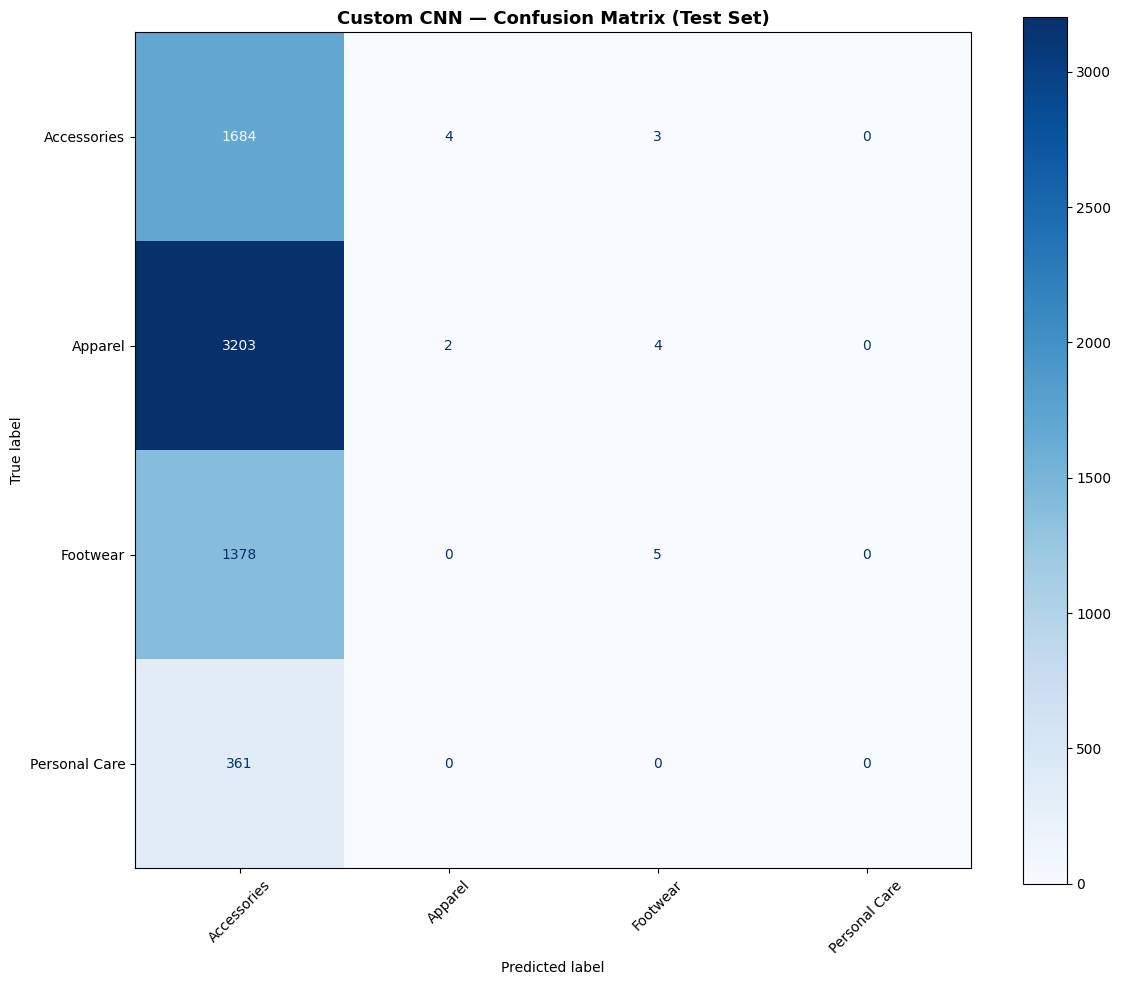

Figure saved: cnn_confusion_matrix.png

Custom CNN — Classification Report:

               precision    recall  f1-score   support

  Accessories     0.2542    0.9959    0.4050      1691
      Apparel     0.3333    0.0006    0.0012      3209
     Footwear     0.4167    0.0036    0.0072      1383
Personal Care     0.0000    0.0000    0.0000       361

     accuracy                         0.2545      6644
    macro avg     0.2510    0.2500    0.1033      6644
 weighted avg     0.3124    0.2545    0.1052      6644


Custom CNN  →  Test Loss: 2.2798  |  Test Accuracy: 0.2545


In [13]:
# Test-set predictions
y_pred_proba_cnn = cnn_model.predict(X_test, verbose=0)
y_pred_cnn       = np.argmax(y_pred_proba_cnn, axis=1)

# ── Confusion Matrix ──
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
class_labels = [idx_to_class[i] for i in range(NUM_CLASSES)]

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=class_labels)
disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45)
ax.set_title("Custom CNN — Confusion Matrix (Test Set)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cnn_confusion_matrix.png", dpi=150)
plt.show()
print("Figure saved: cnn_confusion_matrix.png")

# ── Classification Report ──
report_cnn = classification_report(y_test, y_pred_cnn,
                                    target_names=class_labels, digits=4)
print("\nCustom CNN — Classification Report:\n")
print(report_cnn)

# Save report to file
with open(FIGURES_DIR / "cnn_classification_report.txt", "w") as f:
    f.write("Custom CNN — Classification Report\n\n")
    f.write(report_cnn)

# ── Test Accuracy & Loss ──
test_loss_cnn, test_acc_cnn = cnn_model.evaluate(X_test, y_test, verbose=0)
print(f"\nCustom CNN  →  Test Loss: {test_loss_cnn:.4f}  |  Test Accuracy: {test_acc_cnn:.4f}")

#### ─────────────────────────────────────────────
### SECTION 9: Transfer Learning — MobileNetV2
#### ─────────────────────────────────────────────

In [14]:
# MobileNetV2 expects 96×96 or larger; our 128×128 is fine.
# Strategy: freeze base → train head → unfreeze top layers (fine-tune)

base_mobilenet = MobileNetV2(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,
    weights='imagenet'
)
base_mobilenet.trainable = False   # Phase 1: freeze all base layers

tl_inp = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3), name="input_tl")
x = base_mobilenet(tl_inp, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu', name='fc_tl')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.40)(x)
tl_out = layers.Dense(NUM_CLASSES, activation='softmax', name='tl_predictions')(x)

tl_model = keras.Model(inputs=tl_inp, outputs=tl_out, name="MobileNetV2_TL")
tl_model.summary()

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_tl = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_tl_model.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=0)
]

print("\n── Phase 1: Training classification head (base frozen) ──")
history_tl_phase1 = tl_model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=10,
    validation_data=val_gen,
    validation_steps=val_steps,
    callbacks=callbacks_tl,
    verbose=1
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "MobileNetV2_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_tl (InputLayer)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_tl (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tl_predictions (Dense)          │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,972 (9.87 MB)

 Trainable params: 329,476 (1.26 MB)

 Non-trainable params: 2,258,496 (8.62 MB)


── Phase 1: Training classification head (base frozen) ──
Epoch 1/10
968/968 ━━━━━━━━━━━━━━━━━━━━ 138s 130ms/step - accuracy: 0.6350 - loss: 0.8630 - val_accuracy: 0.3835 - val_loss: 1.5162 - learning_rate: 0.0020
Epoch 2/10
968/968 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6250 - loss: 0.8289 - val_accuracy: 0.3758 - val_loss: 1.5444 - learning_rate: 0.0020
Epoch 3/10
968/968 ━━━━━━━━━━━━━━━━━━━━ 116s 119ms/step - accuracy: 0.6611 - loss: 0.7955 - val_accuracy: 0.3022 - val_loss: 1.9734 - learning_rate: 0.0020
Epoch 4/10
  1/968 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.6875 - loss: 0.6365
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0006000000284984708.
968/968 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6875 - loss: 0.6365 - val_accuracy: 0.3003 - val_loss: 1.9833 - learning_rate: 0.0020
Epoch 5/10
968/968 ━━━━━━━━━━━━━━━━━━━━ 115s 119ms/step - accuracy: 0.6741 - loss: 0.7646 - val_accuracy: 0.3163 - val_loss: 2.1188 - learning_rate: 6.0000e-04
Epoch 6/10
9


── Phase 2: Fine-tuning top 40 layers of MobileNetV2 ──
Epoch 1/20


2026-06-07 17:20:43.345273: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 17:20:43.542768: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


261/968 ━━━━━━━━━━━━━━━━━━━━ 1:22 117ms/step - accuracy: 0.6269 - loss: 0.8951

2026-06-07 17:21:22.599807: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 17:21:22.799403: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


968/968 ━━━━━━━━━━━━━━━━━━━━ 149s 135ms/step - accuracy: 0.6536 - loss: 0.8281 - val_accuracy: 0.5654 - val_loss: 1.2738 - learning_rate: 1.0000e-05
Epoch 2/20
968/968 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6562 - loss: 0.8154 - val_accuracy: 0.5652 - val_loss: 1.2738 - learning_rate: 1.0000e-05
Epoch 3/20
968/968 ━━━━━━━━━━━━━━━━━━━━ 120s 124ms/step - accuracy: 0.6754 - loss: 0.7689 - val_accuracy: 0.5325 - val_loss: 1.5418 - learning_rate: 1.0000e-05
Epoch 4/20
  1/968 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.5938 - loss: 0.8493
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
968/968 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5938 - loss: 0.8493 - val_accuracy: 0.5328 - val_loss: 1.5399 - learning_rate: 1.0000e-05
Epoch 5/20
968/968 ━━━━━━━━━━━━━━━━━━━━ 118s 122ms/step - accuracy: 0.6857 - loss: 0.7519 - val_accuracy: 0.5066 - val_loss: 1.7602 - learning_rate: 3.0000e-06
Epoch 6/20
968/968 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0

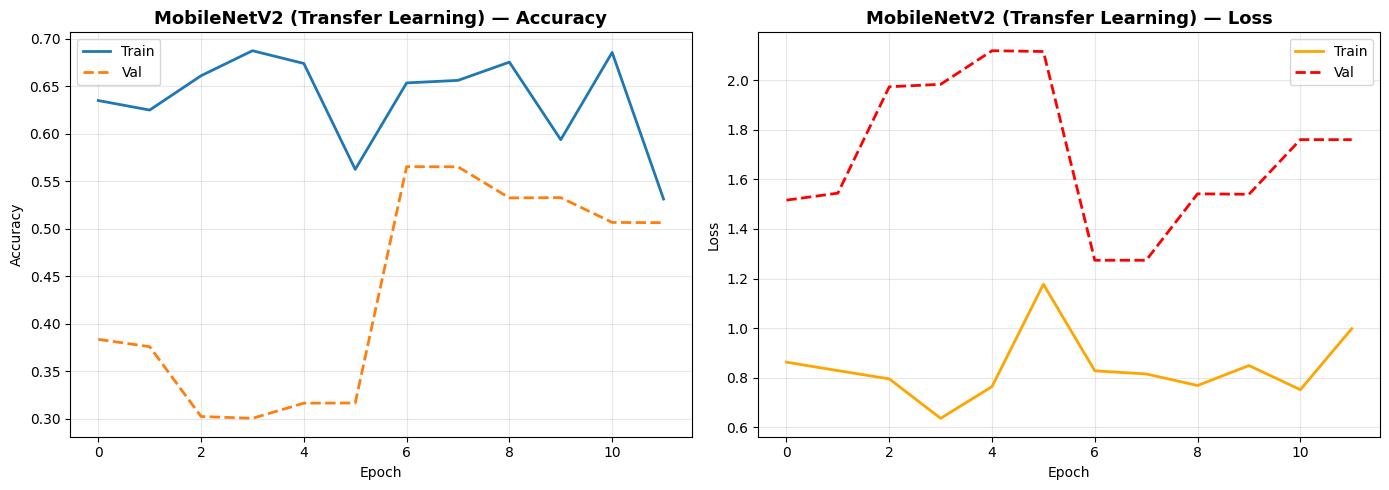

Figure saved: tl_training_curves.png


In [15]:
# ── Phase 2: Fine-tune top 40 layers of MobileNetV2 ──
base_mobilenet.trainable = True
fine_tune_at = len(base_mobilenet.layers) - 40
for layer in base_mobilenet.layers[:fine_tune_at]:
    layer.trainable = False

print(f"\n── Phase 2: Fine-tuning top {40} layers of MobileNetV2 ──")
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),   # Much lower LR for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_tl_phase2 = tl_model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS_TL,
    validation_data=val_gen,
    validation_steps=val_steps,
    callbacks=callbacks_tl,
    verbose=1
)

# Merge histories for plotting
def merge_histories(h1, h2):
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history[key]
    return merged

combined_tl_history = type('obj', (object,), {'history': merge_histories(history_tl_phase1, history_tl_phase2)})()
plot_history(combined_tl_history, "MobileNetV2 (Transfer Learning)",
             save_path=FIGURES_DIR / "tl_training_curves.png")

#### ─────────────────────────────────────────────
### SECTION 10: Evaluate Transfer Learning Model
#### ─────────────────────────────────────────────

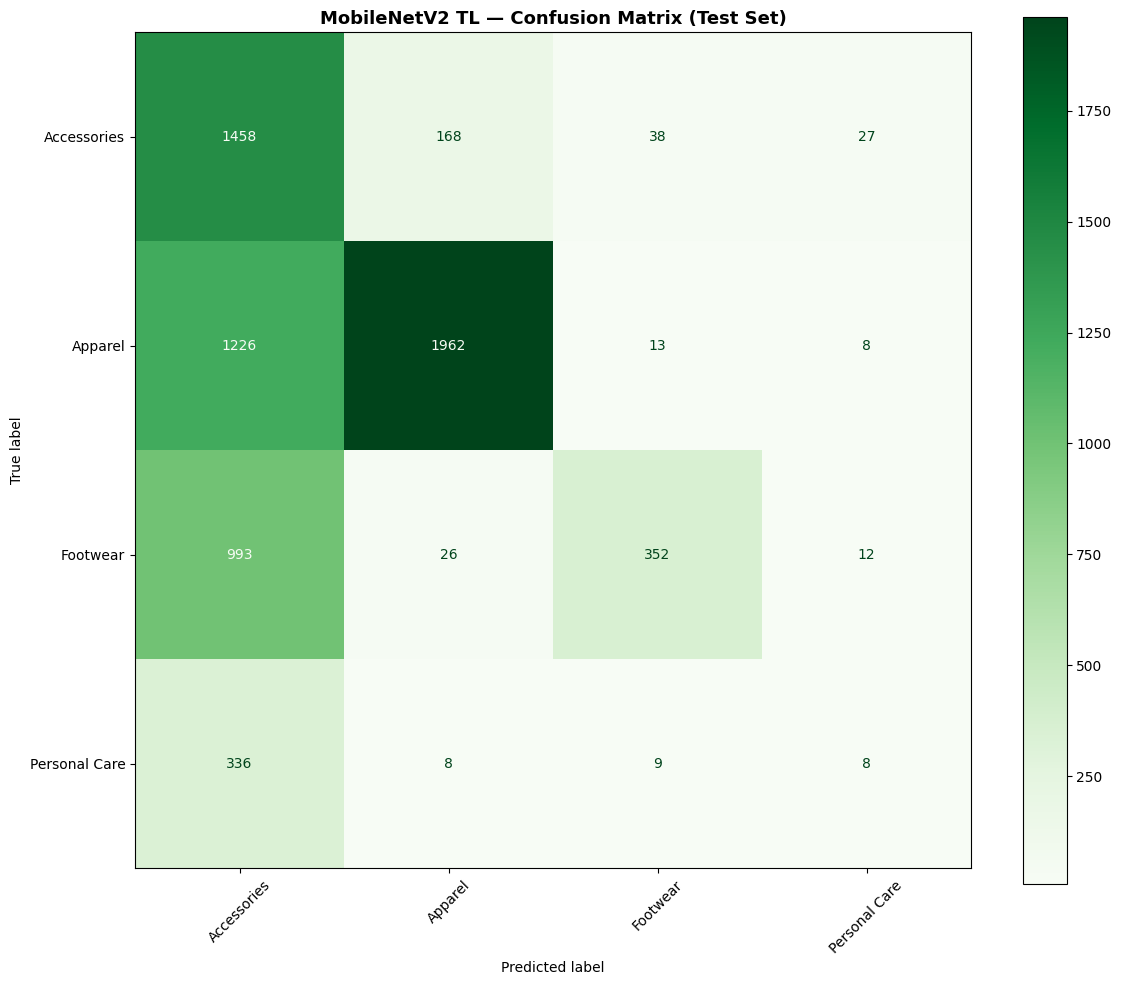

Figure saved: tl_confusion_matrix.png

MobileNetV2 TL — Classification Report:

               precision    recall  f1-score   support

  Accessories     0.3633    0.8622    0.5112      1691
      Apparel     0.9067    0.6114    0.7303      3209
     Footwear     0.8544    0.2545    0.3922      1383
Personal Care     0.1455    0.0222    0.0385       361

     accuracy                         0.5689      6644
    macro avg     0.5674    0.4376    0.4181      6644
 weighted avg     0.7161    0.5689    0.5666      6644


MobileNetV2 TL  →  Test Loss: 1.2782  |  Test Accuracy: 0.5689


In [16]:

y_pred_proba_tl = tl_model.predict(X_test, verbose=0)
y_pred_tl       = np.argmax(y_pred_proba_tl, axis=1)

# ── Confusion Matrix ──
cm_tl = confusion_matrix(y_test, y_pred_tl)
fig, ax = plt.subplots(figsize=(12, 10))
disp_tl = ConfusionMatrixDisplay(confusion_matrix=cm_tl, display_labels=class_labels)
disp_tl.plot(ax=ax, cmap='Greens', colorbar=True, xticks_rotation=45)
ax.set_title("MobileNetV2 TL — Confusion Matrix (Test Set)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "tl_confusion_matrix.png", dpi=150)
plt.show()
print("Figure saved: tl_confusion_matrix.png")

# ── Classification Report ──
report_tl = classification_report(y_test, y_pred_tl,
                                   target_names=class_labels, digits=4)
print("\nMobileNetV2 TL — Classification Report:\n")
print(report_tl)

with open(FIGURES_DIR / "tl_classification_report.txt", "w") as f:
    f.write("MobileNetV2 TL — Classification Report\n\n")
    f.write(report_tl)

test_loss_tl, test_acc_tl = tl_model.evaluate(X_test, y_test, verbose=0)
print(f"\nMobileNetV2 TL  →  Test Loss: {test_loss_tl:.4f}  |  Test Accuracy: {test_acc_tl:.4f}")

#### ─────────────────────────────────────────────
### SECTION 11: Model Comparison Table
#### ─────────────────────────────────────────────


Model Comparison Table:
           Metric  Custom CNN  MobileNetV2 TL
         Accuracy      0.2545          0.5689
  Macro Precision      0.2510          0.5674
     Macro Recall      0.2500          0.4376
   Macro F1-Score      0.1033          0.4181
Weighted F1-Score      0.1052          0.5666
Table saved: model_comparison.csv


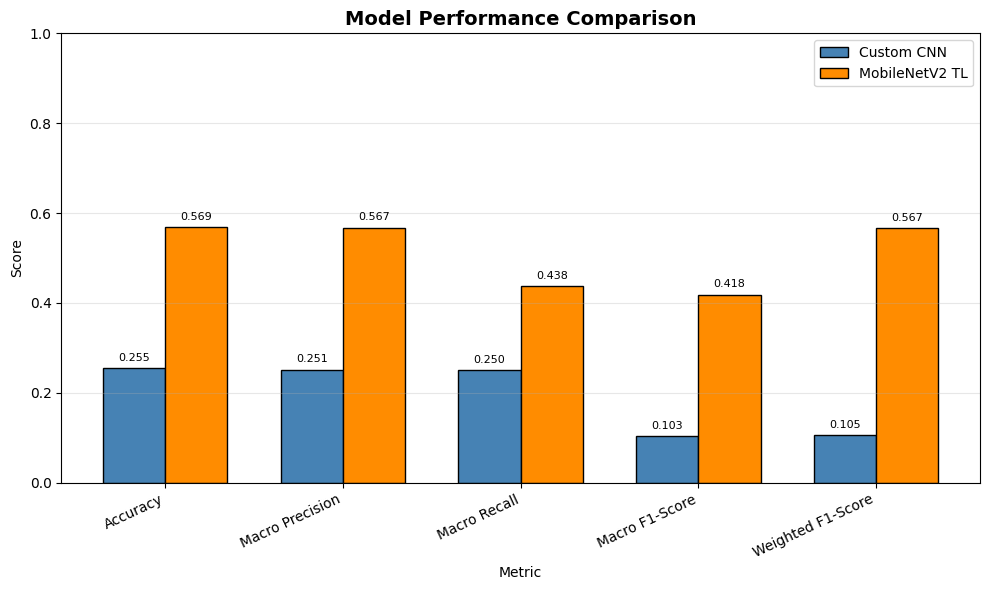

Figure saved: model_comparison_chart.png


In [17]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def compute_metrics(y_true, y_pred):
    return {
        'Accuracy':          round(accuracy_score(y_true, y_pred), 4),
        'Macro Precision':   round(precision_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'Macro Recall':      round(recall_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'Macro F1-Score':    round(f1_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'Weighted F1-Score': round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
    }

metrics_cnn = compute_metrics(y_test, y_pred_cnn)
metrics_tl  = compute_metrics(y_test, y_pred_tl)

comparison_df = pd.DataFrame({
    'Metric':           list(metrics_cnn.keys()),
    'Custom CNN':       list(metrics_cnn.values()),
    'MobileNetV2 TL':   list(metrics_tl.values()),
})
print("\nModel Comparison Table:")
print(comparison_df.to_string(index=False))
comparison_df.to_csv(FIGURES_DIR / "model_comparison.csv", index=False)
print("Table saved: model_comparison.csv")

# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_df))
width = 0.35
bars1 = ax.bar(x - width/2, comparison_df['Custom CNN'],    width, label='Custom CNN',     color='steelblue',  edgecolor='black')
bars2 = ax.bar(x + width/2, comparison_df['MobileNetV2 TL'], width, label='MobileNetV2 TL', color='darkorange', edgecolor='black')
ax.set_title("Model Performance Comparison", fontsize=14, fontweight='bold')
ax.set_xlabel("Metric"); ax.set_ylabel("Score")
ax.set_xticks(x); ax.set_xticklabels(comparison_df['Metric'], rotation=25, ha='right')
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in [*bars1, *bars2]:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison_chart.png", dpi=150)
plt.show()
print("Figure saved: model_comparison_chart.png")

#### ─────────────────────────────────────────────
### SECTION 12: ROC Curves (One-vs-Rest)
#### ─────────────────────────────────────────────

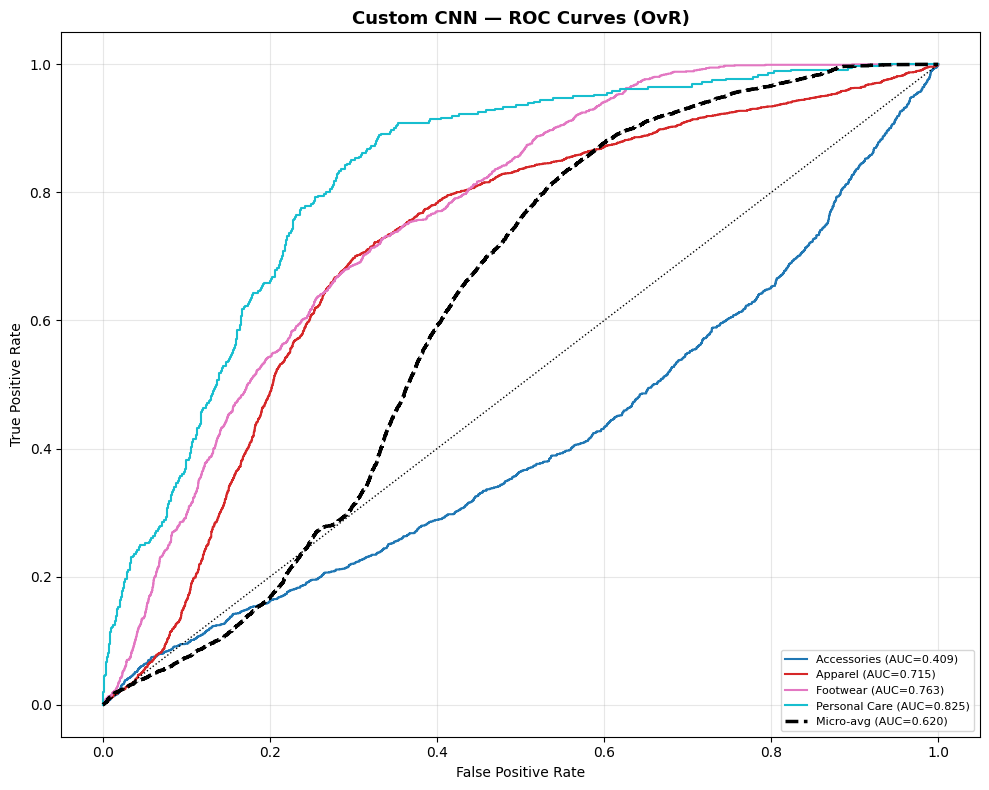

Figure saved: cnn_roc_curves.png


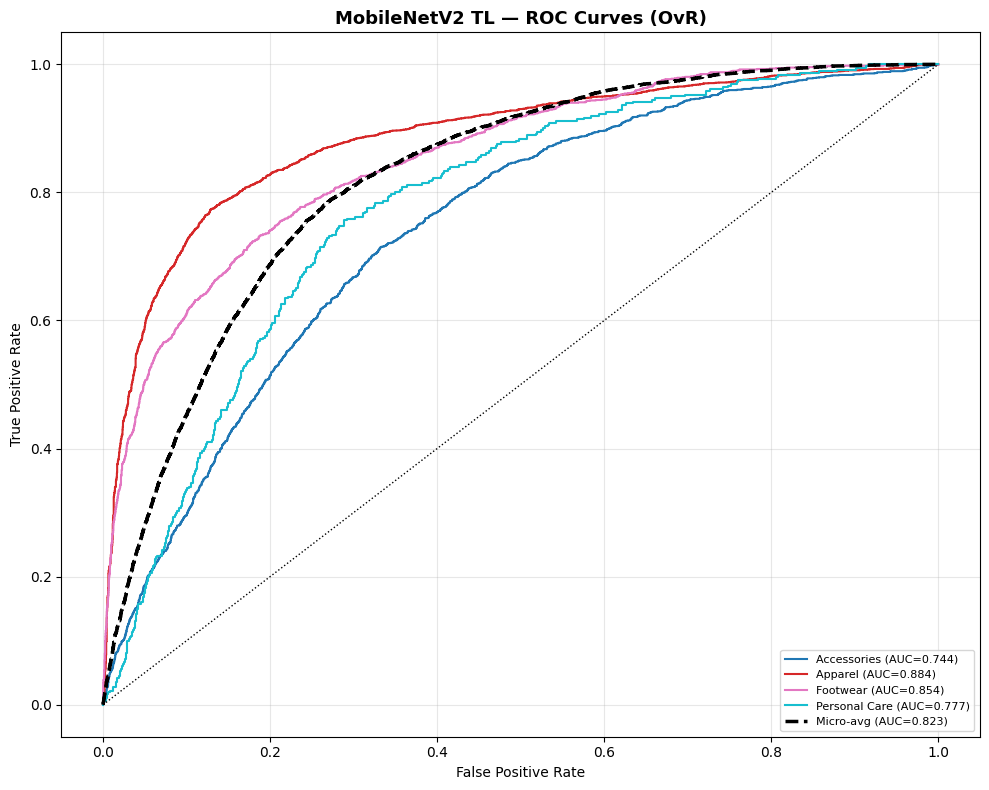

Figure saved: tl_roc_curves.png

Custom CNN    Micro-AUC: 0.6202
MobileNetV2   Micro-AUC: 0.8233


In [18]:
def plot_roc_multiclass(y_true, y_score, class_labels, title, save_path):
    """Compute and plot ROC curve for each class (OvR) + micro-average."""
    y_true_bin = label_binarize(y_true, classes=list(range(len(class_labels))))
    n_classes  = len(class_labels)

    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Micro-average
    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    fig, ax = plt.subplots(figsize=(10, 8))
    cmap = plt.cm.get_cmap('tab10', n_classes)
    for i in range(n_classes):
        ax.plot(fpr[i], tpr[i], color=cmap(i),
                label=f"{class_labels[i]} (AUC={roc_auc[i]:.3f})", linewidth=1.5)
    ax.plot(fpr["micro"], tpr["micro"], color='black', linestyle='--', linewidth=2.5,
            label=f"Micro-avg (AUC={roc_auc['micro']:.3f})")
    ax.plot([0, 1], [0, 1], 'k:', linewidth=1)
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Figure saved: {Path(save_path).name}")
    return roc_auc


roc_auc_cnn = plot_roc_multiclass(y_test, y_pred_proba_cnn, class_labels,
                                   "Custom CNN — ROC Curves (OvR)",
                                   FIGURES_DIR / "cnn_roc_curves.png")

roc_auc_tl  = plot_roc_multiclass(y_test, y_pred_proba_tl,  class_labels,
                                   "MobileNetV2 TL — ROC Curves (OvR)",
                                   FIGURES_DIR / "tl_roc_curves.png")

print(f"\nCustom CNN    Micro-AUC: {roc_auc_cnn['micro']:.4f}")
print(f"MobileNetV2   Micro-AUC: {roc_auc_tl['micro']:.4f}")

#### ─────────────────────────────────────────────
### SECTION 13: Grad-CAM Visualisation
#### ─────────────────────────────────────────────

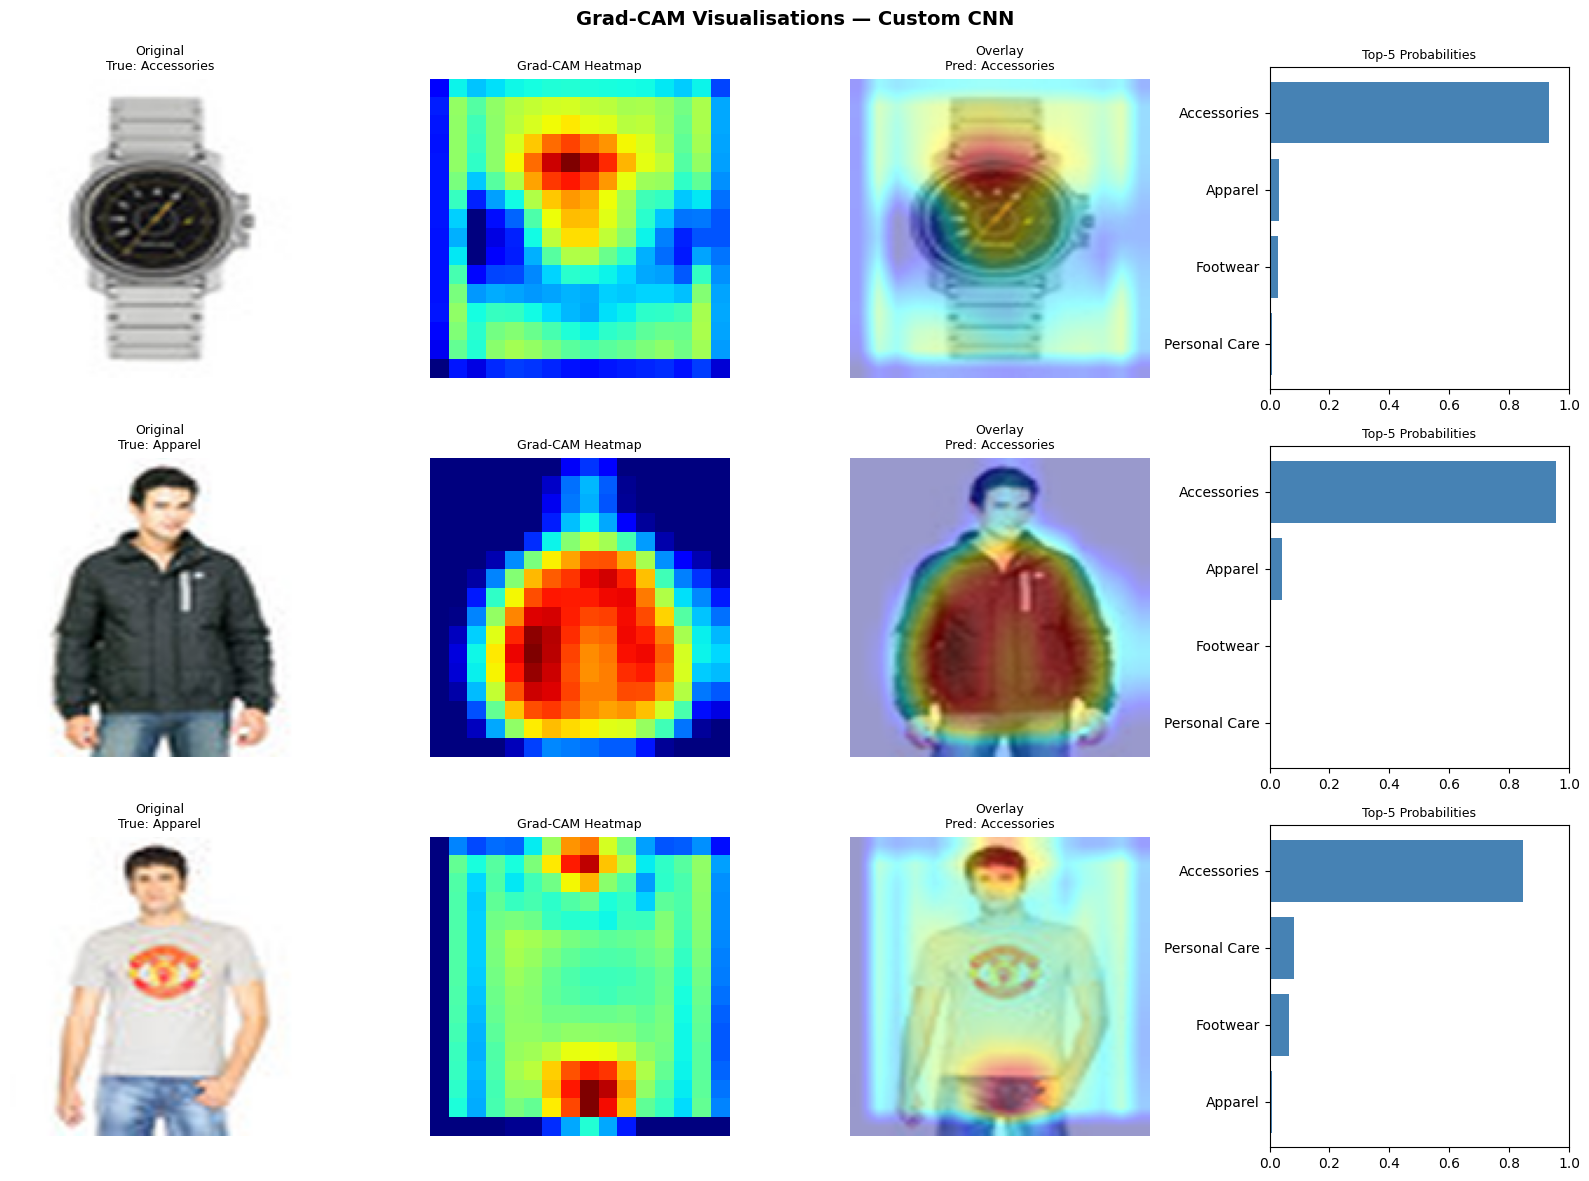

Figure saved: gradcam_visualisations.png


In [19]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    """
    Generate a Grad-CAM heatmap for the predicted class.
    Returns the heatmap as a numpy array.
    """
    grad_model = keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads     = tape.gradient(class_channel, conv_outputs)
    pooled    = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out  = conv_outputs[0]
    heatmap   = conv_out @ pooled[..., tf.newaxis]
    heatmap   = tf.squeeze(heatmap)
    heatmap   = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index.numpy())


def overlay_gradcam(original_img, heatmap, alpha=0.4):
    """Overlay a Grad-CAM heatmap onto the original image."""
    heatmap_resized = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
    heatmap_uint8   = np.uint8(255 * heatmap_resized)
    colored         = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    colored_rgb     = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)
    original_uint8  = np.uint8(255 * original_img)
    superimposed    = cv2.addWeighted(original_uint8, 1 - alpha, colored_rgb, alpha, 0)
    return superimposed


# Use the last conv layer of our custom CNN
last_conv_layer = 'conv4b'

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for row_idx in range(3):
    sample_idx = row_idx * (len(X_test) // 3)
    img        = X_test[sample_idx]
    true_cls   = idx_to_class[y_test[sample_idx]]

    img_tensor = np.expand_dims(img, axis=0)
    try:
        heatmap, pred_idx = make_gradcam_heatmap(img_tensor, cnn_model, last_conv_layer)
        pred_cls  = idx_to_class[pred_idx]
        cam_img   = overlay_gradcam(img, heatmap)

        col = row_idx * 0  # layout offset
        axes[row_idx][0].imshow(img)
        axes[row_idx][0].set_title(f"Original\nTrue: {true_cls}", fontsize=9)
        axes[row_idx][0].axis('off')

        axes[row_idx][1].imshow(heatmap, cmap='jet')
        axes[row_idx][1].set_title("Grad-CAM Heatmap", fontsize=9)
        axes[row_idx][1].axis('off')

        axes[row_idx][2].imshow(cam_img)
        axes[row_idx][2].set_title(f"Overlay\nPred: {pred_cls}", fontsize=9)
        axes[row_idx][2].axis('off')

        # Per-class probability bar
        probs = y_pred_proba_cnn[sample_idx]
        top5  = np.argsort(probs)[::-1][:5]
        axes[row_idx][3].barh([idx_to_class[i] for i in top5[::-1]],
                               probs[top5[::-1]], color='steelblue')
        axes[row_idx][3].set_xlim(0, 1)
        axes[row_idx][3].set_title("Top-5 Probabilities", fontsize=9)
    except Exception as e:
        print(f"  Grad-CAM failed for sample {sample_idx}: {e}")

plt.suptitle("Grad-CAM Visualisations — Custom CNN", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "gradcam_visualisations.png", dpi=150)
plt.show()
print("Figure saved: gradcam_visualisations.png")

#### ─────────────────────────────────────────────
### SECTION 14: Error Analysis
#### ─────────────────────────────────────────────

Total misclassified (CNN): 4953 / 6644  (74.5%)

Top-10 confusion pairs (true → predicted):
  Apparel              → Accessories           (3203 errors)
  Footwear             → Accessories           (1378 errors)
  Personal Care        → Accessories           (361 errors)
  Accessories          → Apparel               (4 errors)
  Apparel              → Footwear              (4 errors)
  Accessories          → Footwear              (3 errors)


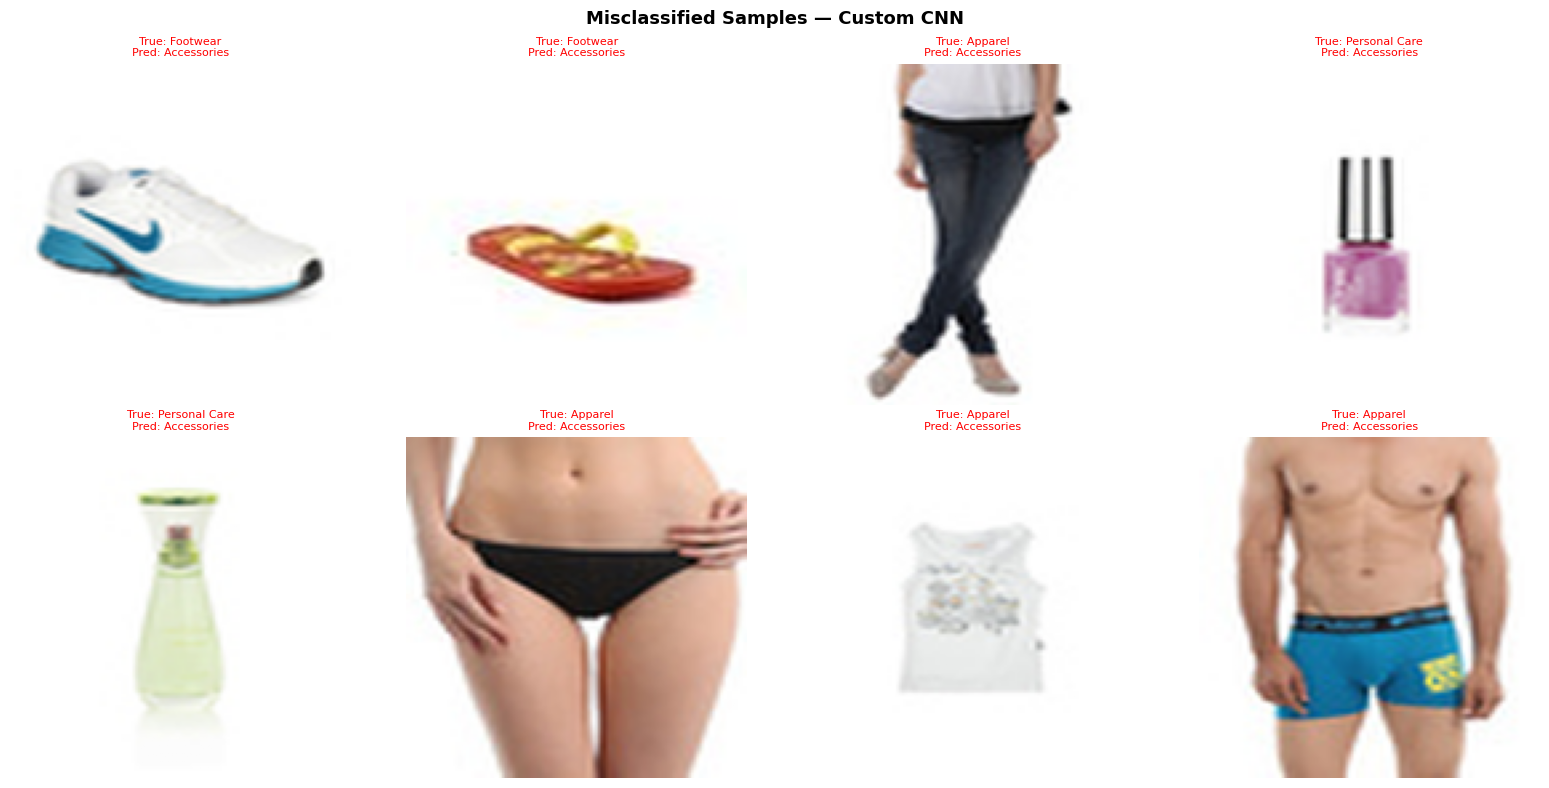

Figure saved: error_analysis.png


In [20]:

# Find misclassified samples
wrong_idx = np.where(y_pred_cnn != y_test)[0]
print(f"Total misclassified (CNN): {len(wrong_idx)} / {len(y_test)}"
      f"  ({100*len(wrong_idx)/len(y_test):.1f}%)")

# Most frequent confusion pairs
wrong_true  = [idx_to_class[y_test[i]]    for i in wrong_idx]
wrong_pred  = [idx_to_class[y_pred_cnn[i]] for i in wrong_idx]
confusion_pairs = Counter(zip(wrong_true, wrong_pred)).most_common(10)
print("\nTop-10 confusion pairs (true → predicted):")
for (t, p), cnt in confusion_pairs:
    print(f"  {t:20s} → {p:20s}  ({cnt} errors)")

# Visualise misclassified images
if len(wrong_idx) >= 8:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    for i, ax in enumerate(axes):
        idx = wrong_idx[i]
        ax.imshow(X_test[idx])
        ax.set_title(f"True: {idx_to_class[y_test[idx]]}\n"
                     f"Pred: {idx_to_class[y_pred_cnn[idx]]}", fontsize=8,
                     color='red' if y_test[idx] != y_pred_cnn[idx] else 'green')
        ax.axis('off')
    plt.suptitle("Misclassified Samples — Custom CNN", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "error_analysis.png", dpi=150)
    plt.show()
    print("Figure saved: error_analysis.png")

#### ─────────────────────────────────────────────
### SECTION 15: Save Models
#### ─────────────────────────────────────────────

In [21]:
cnn_model.save("custom_cnn_final.keras")
tl_model.save("mobilenetv2_tl_final.keras")
print("Models saved: custom_cnn_final.keras | mobilenetv2_tl_final.keras")

Models saved: custom_cnn_final.keras | mobilenetv2_tl_final.keras


#### ─────────────────────────────────────────────
### SECTION 16: Final Summary
#### ─────────────────────────────────────────────

In [22]:
print(f"""
╔══════════════════════════════════════════════════════╗
║           EXPERIMENT RESULTS SUMMARY                ║
╠══════════════════════════════════════════════════════╣
║  Dataset   : Fashion Product Images (Small)         ║
║  Classes   : {NUM_CLASSES:<44}║
║  Train     : {len(X_train):<44}║
║  Val       : {len(X_val):<44}║
║  Test      : {len(X_test):<44}║
╠══════════════════════════════════════════════════════╣
║  Custom CNN Test Accuracy   : {test_acc_cnn:.4f}                  ║
║  MobileNetV2 TL Test Acc   : {test_acc_tl:.4f}                  ║
║  CNN Micro-AUC             : {roc_auc_cnn['micro']:.4f}                  ║
║  MobileNetV2 Micro-AUC     : {roc_auc_tl['micro']:.4f}                  ║
╚══════════════════════════════════════════════════════╝
""")

print("All figures saved to:", FIGURES_DIR.resolve())
print("\nDone!")


╔══════════════════════════════════════════════════════╗
║           EXPERIMENT RESULTS SUMMARY                ║
╠══════════════════════════════════════════════════════╣
║  Dataset   : Fashion Product Images (Small)         ║
║  Classes   : 4                                           ║
║  Train     : 31001                                       ║
║  Val       : 6643                                        ║
║  Test      : 6644                                        ║
╠══════════════════════════════════════════════════════╣
║  Custom CNN Test Accuracy   : 0.2545                  ║
║  MobileNetV2 TL Test Acc   : 0.5689                  ║
║  CNN Micro-AUC             : 0.6202                  ║
║  MobileNetV2 Micro-AUC     : 0.8233                  ║
╚══════════════════════════════════════════════════════╝

All figures saved to: /kaggle/working/figures

Done!
